# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configure inline plotting
%matplotlib inline

In [57]:
# Load your uploaded file (path "/content/listings.csv.gz") 🔧
df = pd.read_csv('/content/listings.csv.gz')

# Display the shape of the dataset and the first few rows
print(f"Dataset loaded successfully. Shape: {df.shape}")
df.head()

Dataset loaded successfully. Shape: (30259, 90)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20260614073253,2026-06-15,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,5.00,4.78,4.78,NaN,NaN,5,0,5,0,0.08
1,6848,https://www.airbnb.com/rooms/6848,20260614073253,2026-06-14,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.80,4.69,4.59,NaN,NaN,1,1,0,0,0.95
2,6872,https://www.airbnb.com/rooms/6872,20260614073253,2026-06-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.00,5.00,5.00,NaN,NaN,2,0,2,0,0.04
3,6990,https://www.airbnb.com/rooms/6990,20260614073253,2026-06-14,city scrape,UES Beautiful Blue Room,Beautiful peaceful healthy home,NaN,https://a0.muscache.com/pictures/45fb4ec7-6856...,16800,...,4.94,4.85,4.84,NaN,NaN,1,0,1,0,1.24
4,7097,https://www.airbnb.com/rooms/7097,20260614073253,2026-06-14,city scrape,"Perfect for Your Parents, With Garden & Patio",Parents/grandparents coming to town or are you...,NaN,https://a0.muscache.com/pictures/aaac19fc-4b4d...,17571,...,4.93,4.95,4.82,NaN,NaN,2,0,2,0,2.12


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

In [58]:
# Count the null values of each column
null_counts = df.isnull().sum()

# Display the columns and their respective null counts
pd.set_option('display.max_rows', 100)
print(null_counts)

id                                                  0
listing_url                                         0
scrape_id                                           0
last_scraped                                        0
source                                              0
name                                                1
description                                       902
neighborhood_overview                           30259
picture_url                                         0
host_id                                             0
host_url                                            0
host_profile_id                                   349
host_profile_url                                  349
host_name                                         349
host_since                                      30259
hosts_time_as_user_years                          349
hosts_time_as_user_months                         349
hosts_time_as_host_years                          349
hosts_time_as_host_months   

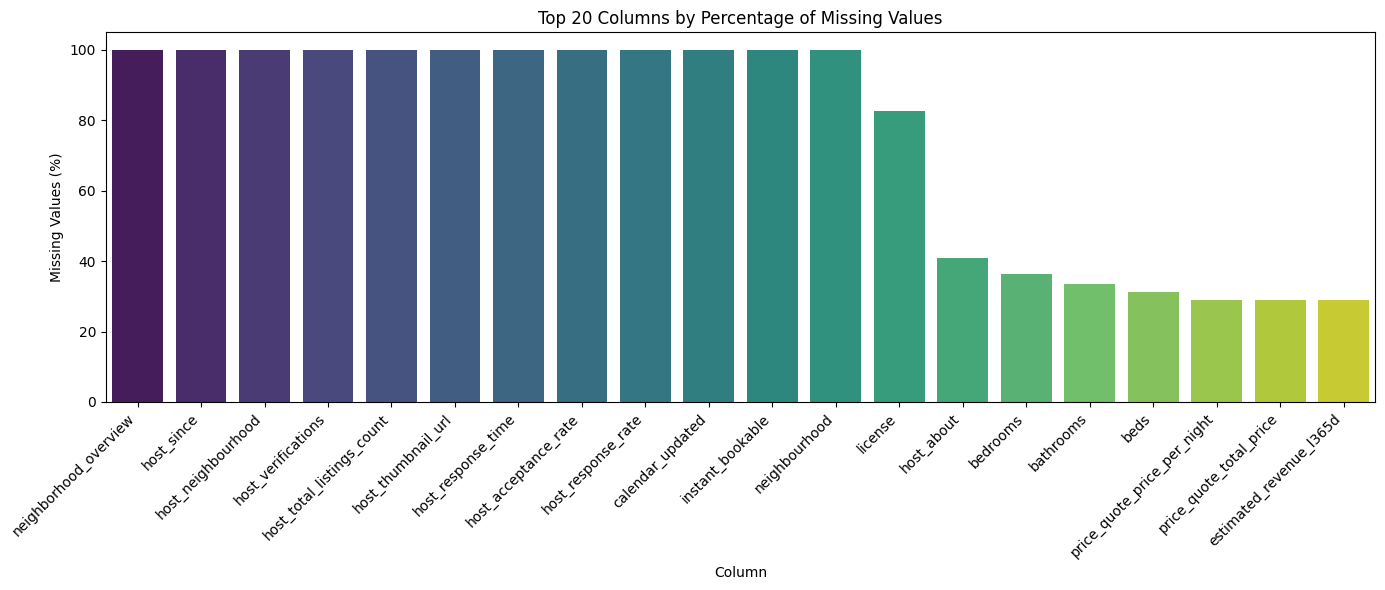

In [59]:
# Percentage of missing values per column
missing_percent = null_counts / len(df) * 100
top_missing = missing_percent[missing_percent > 0].sort_values(ascending=False).head(20)

# Bar chart of the 20 columns with the most missing values
plt.figure(figsize=(14, 6))
sns.barplot(x=top_missing.index, y=top_missing.values, hue=top_missing.index, palette='viridis', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Columns by Percentage of Missing Values')
plt.ylabel('Missing Values (%)')
plt.xlabel('Column')
plt.tight_layout()
plt.show()

In [60]:
# Identify columns missing more than 50% of their data
high_missing_cols = missing_percent[missing_percent > 50].sort_values(ascending=False)

print("Columns missing more than 50% of their values:")
print(high_missing_cols)

Columns missing more than 50% of their values:
neighborhood_overview        100.000000
host_since                   100.000000
host_response_time           100.000000
host_response_rate           100.000000
host_acceptance_rate         100.000000
host_thumbnail_url           100.000000
host_neighbourhood           100.000000
host_total_listings_count    100.000000
host_verifications           100.000000
neighbourhood                100.000000
calendar_updated             100.000000
instant_bookable             100.000000
license                       82.530817
dtype: float64


### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. Twelve columns are completely empty, so the top three are tied at 100% missing. The first three on the sorted list are neighborhood_overview, host_since, and host_response_time. License follows at about 83%.

2. Price is missing for about 29% of listings and review scores for about 28%. Those gaps would break a pricing model or any dashboard that ranks listings by quality. Missing bedroom and bathroom counts would also weaken comparisons between similar properties.

3. The twelve empty columns can be dropped safely because they contain no data. License could also go unless a policy team needs it for compliance review.


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [61]:
# Drop columns that are completely empty
columns_to_drop = ['calendar_updated', 'host_response_time', 'host_acceptance_rate', 'host_response_rate']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Confirm that the columns are removed and print the new shape
print(f"Dropped columns: {columns_to_drop}")
print(f"New dataset shape: {df.shape}")

# Display summary info to verify
df.info()

Dropped columns: ['calendar_updated', 'host_response_time', 'host_acceptance_rate', 'host_response_rate']
New dataset shape: (30259, 86)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30259 entries, 0 to 30258
Data columns (total 86 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            30259 non-null  int64  
 1   listing_url                                   30259 non-null  object 
 2   scrape_id                                     30259 non-null  int64  
 3   last_scraped                                  30259 non-null  object 
 4   source                                        30259 non-null  object 
 5   name                                          30258 non-null  object 
 6   description                                   29357 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8  

### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. I dropped calendar_updated, host_response_time, host_acceptance_rate, and host_response_rate.

2. All four columns were empty in this scrape. calendar_updated would show how recently a host updated availability, and the three host fields would measure how quickly and how often hosts respond to and accept guests. Each would matter to a host manager, but a column with no values cannot support any decision.

3. Empty columns clutter the dataset and slow down anyone who works with it. A teammate might also assume the fields hold real values and build a metric on them, and that metric would return nothing useful.



## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [62]:
# Fill missing ratings with the median rating
rating_median = df['review_scores_rating'].median()
print(f"Median review score: {rating_median}")
df['review_scores_rating'] = df['review_scores_rating'].fillna(rating_median)

# Fill missing descriptions with a placeholder
df['description'] = df['description'].fillna('No description provided')

# Confirm no missing values remain in either column
print("Missing review_scores_rating:", df['review_scores_rating'].isnull().sum())
print("Missing description:", df['description'].isnull().sum())

Median review score: 4.86
Missing review_scores_rating: 0
Missing description: 0


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. I cleaned review_scores_rating and description.

2. I filled review_scores_rating with the median of 4.86 because ratings cluster near the top of the five-point scale and the median is not pulled down by a few low scores. I filled description with "No description provided" because text cannot be averaged, and the placeholder keeps the row while marking the gap.

3. Most missing ratings belong to listings with no reviews. The median fill makes a new listing look as proven as an established one. A separate flag for unreviewed listings would be the safer choice before any ranking or pricing analysis.


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

In [63]:
# Check the data type and sample values of price
print("Data type of price:", df['price'].dtype)
print(df['price'].head(10))

Data type of price: object
0    $113.97
1    $117.27
2     $80.06
3     $77.17
4    $202.47
5    $365.97
6    $154.87
7     $91.07
8        NaN
9        NaN
Name: price, dtype: object


Data type: float64
Missing values: 0
count    30259.000000
mean       248.309509
std        450.815085
min          4.580000
25%        127.470000
50%        174.690000
75%        237.690000
max      30972.960000
Name: price, dtype: float64


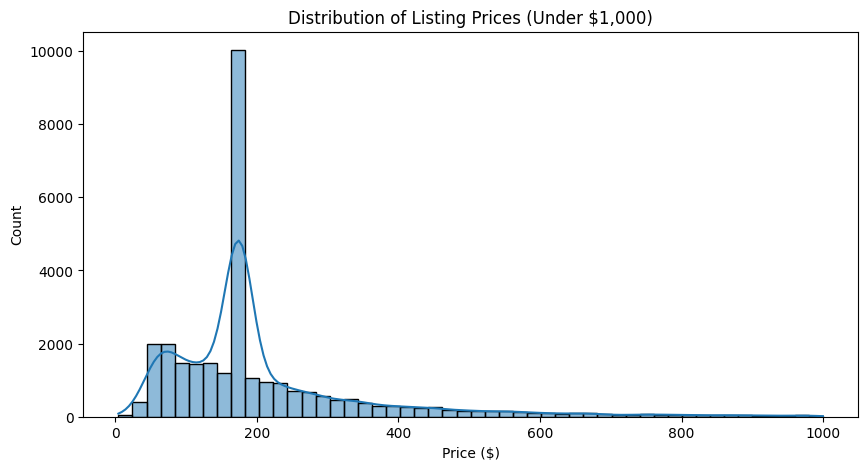

In [64]:
# Remove dollar signs and commas, then convert price to a number
df['price'] = pd.to_numeric(df['price'].str.replace('[$,]', '', regex=True), errors='coerce')

# Fill missing prices with the median price
price_median = df['price'].median()
df['price'] = df['price'].fillna(price_median)

# Check the cleaned column
print(f"Data type: {df['price'].dtype}")
print(f"Missing values: {df['price'].isnull().sum()}")
print(df['price'].describe())

# Plot prices under $1,000 so the long tail does not flatten the chart
plt.figure(figsize=(10, 5))
sns.histplot(df.loc[df['price'] < 1000, 'price'], bins=50, kde=True)
plt.title('Distribution of Listing Prices (Under $1,000)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. I fixed the price column.

2. Price was stored as text with dollar signs. I removed those characters, converted the column to a number, and filled missing values with the median of about $175. I checked the result with summary statistics and a histogram.

3. Price can now be used in calculations, charts, and models. The fill does have a cost. About 29% of prices now sit at the median, which flattens the distribution, and the $31,000 maximum suggests outliers that need review.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [65]:
# Check for exact duplicate rows and repeated listing IDs
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate listing IDs: {df.duplicated(subset=['id']).sum()}")

# Keep the first record for each listing ID
df = df.drop_duplicates(subset=['id'], keep='first')
print(f"Shape after removing duplicates: {df.shape}")

Exact duplicate rows: 0
Duplicate listing IDs: 0
Shape after removing duplicates: (30259, 86)


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1. No. The dataset had no exact duplicate rows and no repeated listing IDs.

2. I checked the id column because each listing should appear once. If duplicates had appeared, I would have kept the first record for each ID and dropped the rest.

3. Duplicate listings inflate supply counts and revenue estimates. They also distort average prices by neighborhood, and a team could make pricing or policy decisions based on listings that do not exist.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [66]:
# Drop the remaining columns that contain no values
empty_cols = df.columns[df.isnull().all()]
df = df.drop(columns=empty_cols)
print(f"Dropped {len(empty_cols)} empty columns: {list(empty_cols)}")

# Export the cleaned dataset for Assignment 7
df.to_csv('cleaned_airbnb_data_6.csv', index=False)
print(f"Final dataset shape: {df.shape}")

Dropped 8 empty columns: ['neighborhood_overview', 'host_since', 'host_thumbnail_url', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'instant_bookable']
Final dataset shape: (30259, 78)


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. Section 4 was the most challenging. The code was simple, but the fill method required judgment about what each missing value meant. The difficulty came from the class concepts more than the coding.

2. I filled missing prices with the median instead of dropping those rows. Dropping them would have removed nearly a third of the dataset. The median kept the listings usable, although it hides real variation in price.

3. Pricing analysts can now compare rates across neighborhoods and room types without fixing text formatting first, as long as they set aside the median-filled prices. Hosts could use the same data to see how their prices compare to similar listings nearby.

4. I would add a flag for listings with no reviews and investigate the price outliers. I would also try to recover missing bedroom and bathroom counts from the bathrooms_text and description fields.


5. My learning outcome is to build a Python workflow that cleans and consistently categorizes messy transaction data. This assignment practiced the first half of that goal. The choice between a median fill and a flag mirrors the choice in diligence work, where an analyst must decide whether an item is normal or deserves attention.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [67]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_06_data_cleaning.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=Tru